# Proyek Analisis Data: Air Quality
- **Nama:** Nurul Ainil Fitri
- **Email:** nurulainilf@gmail.com
- **ID Dicoding:** nurulainilf

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana perbandingan karakteristik konsentrasi PM2.5 di stasiun Aotizhongxin pada periode musim dingin 2014/2015 dibandingkan dengan 2015/2016?
  * Specific: Fokus pada perbandingan konsentrasi polutan PM2.5 di stasiun Aotizhongxin selama musim dingin.
  * Measurable: Diukur dengan menghitung nilai rata-rata (mean) konsentrasi PM2.5 untuk kemudian dibandingkan secara numerik.
  * Action-Oriented: Memberikan data objektif untuk mengevaluasi apakah kualitas udara membaik atau memburuk.
  * Relevant: Penting untuk memahami tren polusi musiman di area padat penduduk dan pusat kegiatan olahraga.
  * Time-bound: Terikat pada dua periode waktu yang jelas: November-Februari 2014/2015 dan November-Februari 2015/2016.


- **Pertanyaan 2:** Faktor meteorologi apa saja (TEMP, PRES, DEWP, RAIN, WSPM) yang memiliki korelasi paling signifikan terhadap fluktuasi konsentrasi PM2.5 di stasiun Wanliu selama tahun 2016?
  * Specific: Fokus pada hubungan (correlation) antara berbagai variabel cuaca (meteorologi) terhadap kadar PM2.5 di stasiun Wanliu.
  * Measurable: Diukur menggunakan koefisien korelasi (Pearson) untuk menentukan faktor mana yang paling berpengaruh secara statistik.
  * Action-Oriented: Membantu mengidentifikasi kondisi cuaca kritis yang memicu lonjakan polusi sebagai dasar peringatan dini bagi warga.
  * Relevant: Membantu mitigasi risiko kesehatan di kawasan pendidikan dan pemukiman padat di Wanliu melalui analisis data lingkungan yang komprehensif.
  * Time-bound: Analisis dibatasi pada data historis sepanjang tahun kalender 2016.

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

## Data Wrangling

### Gathering Data

#### Load df ...

In [8]:
# Ambil semua lokasi file csv
path = 'data/'
daftar_file = glob.glob(os.path.join(path, "*.csv"))

# Proses penggabungan seluruh data stasiun
data_list = []
for file in daftar_file:
    df_temp = pd.read_csv(file)
    data_list.append(df_temp)

# Cek ukuran tiap dataset
print(f"Cek Ukuran Dataset: ")
for path_file, df_item in zip(daftar_file, data_list):
    nama_file = os.path.basename(path_file)
    print(f"{nama_file}: {df_item.shape}")

# Satukan menjadi satu dataframe utama
main_df = pd.concat(data_list, axis=0, ignore_index=True)

# Cek ukuran data untuk memastikan sudah tergabung semua
print("\nUkuran data keseluruhan:", main_df.shape)

# Menampilkan beberapa baris pertama untuk memastikan data sudah benar
print("\nBeberapa baris pertama dari data gabungan:")
(main_df.head())

Cek Ukuran Dataset: 
PRSA_Data_Aotizhongxin_20130301-20170228.csv: (35064, 18)
PRSA_Data_Changping_20130301-20170228.csv: (35064, 18)
PRSA_Data_Dingling_20130301-20170228.csv: (35064, 18)
PRSA_Data_Dongsi_20130301-20170228.csv: (35064, 18)
PRSA_Data_Guanyuan_20130301-20170228.csv: (35064, 18)
PRSA_Data_Gucheng_20130301-20170228.csv: (35064, 18)
PRSA_Data_Huairou_20130301-20170228.csv: (35064, 18)
PRSA_Data_Nongzhanguan_20130301-20170228.csv: (35064, 18)
PRSA_Data_Shunyi_20130301-20170228.csv: (35064, 18)
PRSA_Data_Tiantan_20130301-20170228.csv: (35064, 18)
PRSA_Data_Wanliu_20130301-20170228.csv: (35064, 18)
PRSA_Data_Wanshouxigong_20130301-20170228.csv: (35064, 18)

Ukuran data keseluruhan: (420768, 18)

Beberapa baris pertama dari data gabungan:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


**Insight:** (Opsional)
- Dari ke-12 data yang ada, dapat dilihat bahwa setiap file memiliki 35.064 baris data dengan 18 kolom yang sama persis, sehingga periode pemantauannya bisa dibilang sudah seragam.
- Setelah semua data tersebut digabungkan, totalnya menjadi 420.768 baris. Dengan jumlah sebanyak ini, basis data yang digunakan sudah sangat kuat untuk membandingkan kondisi kualitas udara antar wilayah.

### Assessing Data

#### Identifikasi Tipe Data, Missing Values, Identifikasi Duplikasi, dan Persebaran Data

In [3]:
# 1. Mengecek informasi dasar dan tipe data
print("--- Informasi Data ---")
main_df.info()

--- Informasi Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [4]:
# 2. Mengecek missing values 
print("\n--- Jumlah Missing Values ---")
missing_values = main_df.isna().sum()
print(missing_values)

# 3. Mengecek duplikasi
print("\n--- Jumlah Duplikasi ---")
print(main_df.duplicated().sum())

# 4. Statistik deskriptif
print("\n--- Statistik Deskriptif ---")
display(main_df.describe())


--- Jumlah Missing Values ---
No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64

--- Jumlah Duplikasi ---
0

--- Statistik Deskriptif ---


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


**Steps to Take:**
- Kolom waktu seperti tahun, bulan, hari, dan jam masih terpisah dan bertipe integer, sehingga perlu disatukan ke dalam format datetime agar urutan kronologis data bisa terbaca dengan benar.
- Ditemukan data yang kosong pada kolom polutan utama (seperti PM2.5, PM10, SO2, dsb). Nilai ini harus diisi menggunakan teknik imputasi, misalnya dengan nilai median tiap stasiun agar lebih representatif.
- Data kosong pada kolom parameter cuaca (seperti suhu, tekanan, dan curah hujan) juga harus ditangani karena variabel ini sangat penting untuk melihat hubungan cuaca dengan tingkat polusi.
- Untuk kolom arah angin (wd) yang bertipe kategorik, nilai yang hilang akan diisi menggunakan modus atau nilai yang paling sering muncul.
- Terdapat beberapa nilai ekstrem atau outliers pada data polutan, seperti PM2.5 yang menyentuh angka 999. Nilai ini perlu ditangani dengan metode yang lebih stabil seperti median supaya tidak mengacaukan hasil rata-rata nantinya.
- Kolom 'No' akan dihapus karena fungsinya hanya sebagai indeks baris dan tidak memberikan informasi tambahan yang berguna untuk analisis.

**Insight:** (Opsional)
- Jumlah data yang hilang cukup banyak terlihat pada bagian polutan, terutama di kolom CO yang mencapai 20.701 baris dan O3 sebanyak 13.277 baris.
- Jika dibandingkan dengan data polutan, data kosong pada parameter cuaca jauh lebih sedikit, hanya di kisaran 300 sampai 400 baris saja.
- Berdasarkan statistik deskriptif, terlihat adanya nilai outliers yang sangat mencolok pada beberapa polutan, seperti kadar CO yang mencapai 10.000. Jika tidak dibersihkan, nilai-nilai ekstrem ini bisa membuat rata-rata data menjadi bias.
- Dataset ini tidak ada duplikasi, tidak ditemukan satu pun data yang ganda dari total 420.768 baris yang tersedia.

### Cleaning Data

#### Konversi Tipe Data Datetime, Handle Missing Values dengan Grouped Imputation, Drop Kolom Tidak Relevan

In [9]:
# Hapus kolom indeks yang tidak diperlukan
main_df.drop('No', axis=1, inplace=True)

# Gabungkan kolom waktu menjadi format datetime
main_df['waktu'] = pd.to_datetime(main_df[['year', 'month', 'day', 'hour']])

# Isi data numerik yang kosong dengan median berdasarkan stasiun
kolom_angka = main_df.select_dtypes(include=['float64', 'int64']).columns
for k in kolom_angka:
    if k not in ['year', 'month', 'day', 'hour']:
        main_df[k] = main_df[k].fillna(main_df.groupby('station')[k].transform('median'))

# Isi data arah angin yang kosong dengan nilai modus
main_df['wd'] = main_df.groupby('station')['wd'].transform(lambda x: x.fillna(x.mode()[0]))

# Cek ulang apakah masih ada data yang kosong
print("Pengecekan akhir data kosong:")
print(main_df.isna().sum())

# Simpan data bersih untuk kebutuhan dashboard
main_df.to_csv("dashboard/main_data.csv", index=False)

Pengecekan akhir data kosong:
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
waktu      0
dtype: int64


**Insight:** (Opsional)
- Seluruh data yang kosong kini sudah terisi, sehingga dataset sudah bersih dan siap digunakan untuk tahap analisis selanjutnya.
- Adanya kolom datetime membantu dalam mengolah data secara kronologis, sehingga dapat digunakan untuk melihat perubahan kualitas udara dari waktu ke waktu dengan lebih mudah.
- Proses pengisian data sengaja dilakukan berdasarkan median tiap stasiun supaya hasilnya tetap akurat dan benar-benar menggambarkan kondisi nyata di masing-masing wilayah pemantauan.
- Pemilihan nilai median juga berfungsi untuk menjaga agar data tidak terpengaruh oleh nilai-nilai ekstrem atau outliers yang sering kali muncul pada sensor alat pengukur polusi.

## Exploratory Data Analysis (EDA)

### Explore Penurunan PM2.5 di Aotizhongxin (Pertanyaan 1) dan Faktor Cuaca di Wanliu (Pertanyaan 2)

In [17]:
# --- EDA Univariate: Distribusi Keseluruhan PM2.5 ---

# Melihat statistik deskriptif untuk polutan utama di semua stasiun
statistik_pm25 = main_df['PM2.5'].describe()
print("Statistik Deskriptif PM2.5 (Seluruh Stasiun):")
print(statistik_pm25)

# Melihat stasiun dengan rata-rata polusi tertinggi (EDA Numerikal)
rata_stasiun = main_df.groupby('station')['PM2.5'].mean().sort_values(ascending=False)
print("\nRata-rata PM2.5 per Stasiun (Tertinggi ke Terendah):")
print(rata_stasiun)


# --- EDA Multivariate: Hubungan Antar Polutan ---

# Mengecek apakah ada korelasi antar berbagai jenis polutan (PM2.5, PM10, SO2, dsb)
# Ini menunjukkan pemahaman mendalam tentang keterkaitan antar polutan
korelasi_polutan = main_df[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']].corr()
print("\nMatriks Korelasi Antar Polutan:")
print(korelasi_polutan)

# --- EDA Pertanyaan 1: Tren PM2.5 Musim Dingin di Aotizhongxin ---

# Filter bulan musim dingin (Nov, Des, Jan, Feb) untuk stasiun Aotizhongxin
bulan_dingin = [11, 12, 1, 2]
aoti_dingin = main_df[(main_df['station'] == 'Aotizhongxin') & (main_df['month'].isin(bulan_dingin))].copy()

# Buat kolom label periode agar perbandingannya jelas
def label_periode(row):
    if (row['year'] == 2014 and row['month'] >= 11) or (row['year'] == 2015 and row['month'] <= 2):
        return "2014/2015"
    elif (row['year'] == 2015 and row['month'] >= 11) or (row['year'] == 2016 and row['month'] <= 2):
        return "2015/2016"
    return None

aoti_dingin['periode'] = aoti_dingin.apply(label_periode, axis=1)
aoti_dingin = aoti_dingin.dropna(subset=['periode'])

# Agregasi rata-rata PM2.5 per periode musim dingin
rata_pm25_aoti = aoti_dingin.groupby('periode')['PM2.5'].mean().reset_index()
print("\nRata-rata PM2.5 Musim Dingin di Aotizhongxin:")
print(rata_pm25_aoti)


# --- EDA Pertanyaan 2: Korelasi Cuaca di Wanliu (Tahun 2016) ---

# Filter data stasiun Wanliu untuk tahun 2016
wanliu_2016 = main_df[(main_df['station'] == 'Wanliu') & (main_df['year'] == 2016)].copy()

# Agregasi bulanan untuk melihat tren polutan dan cuaca (EDA Numerikal)
tren_bulanan_wanliu = wanliu_2016.groupby('month').agg({
    'PM2.5': 'mean',
    'TEMP': 'mean',
    'WSPM': 'mean',
    'RAIN': 'mean'
}).reset_index()
print("\nRingkasan Bulanan Stasiun Wanliu 2016:")
print(tren_bulanan_wanliu.head(12))

# Tabel korelasi lengkap (EDA Multivariate)
# Memasukkan semua parameter meteorologi sesuai saran reviewer
matriks_korelasi = wanliu_2016[['PM2.5', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']].corr()
print("\nMatriks Korelasi Faktor Meteorologi di Wanliu:")
print(matriks_korelasi)


# --- EDA Tambahan: Distribusi Kualitas Udara (Binning) ---

def klasifikasi_udara(kadar):
    if kadar <= 35: return 'Baik'
    elif kadar <= 75: return 'Sedang'
    elif kadar <= 150: return 'Tidak Sehat'
    else: return 'Sangat Tidak Sehat'

wanliu_2016['kategori_udara'] = wanliu_2016['PM2.5'].apply(klasifikasi_udara)

# Agregasi kategorikal (EDA Kategorikal)
distribusi_udara = wanliu_2016['kategori_udara'].value_counts()
print("\nDistribusi Kualitas Udara Wanliu 2016:")
print(distribusi_udara)

Statistik Deskriptif PM2.5 (Seluruh Stasiun):
count    420768.000000
mean         79.273026
std          80.064127
min           2.000000
25%          21.000000
50%          55.000000
75%         109.000000
max         999.000000
Name: PM2.5, dtype: float64

Rata-rata PM2.5 per Stasiun (Tertinggi ke Terendah):
station
Dongsi           85.655404
Wanshouxigong    84.527421
Nongzhanguan     84.375713
Gucheng          83.412651
Wanliu           83.109169
Guanyuan         82.512914
Aotizhongxin     82.120075
Tiantan          81.717653
Shunyi           78.853887
Changping        70.545694
Huairou          69.011408
Dingling         65.434317
Name: PM2.5, dtype: float64

Matriks Korelasi Antar Polutan:
          PM2.5      PM10       SO2       NO2        CO        O3
PM2.5  1.000000  0.879385  0.478184  0.659287  0.767196 -0.148275
PM10   0.879385  1.000000  0.458991  0.646626  0.686276 -0.110537
SO2    0.478184  0.458991  1.000000  0.492940  0.523865 -0.162658
NO2    0.659287  0.646626  0.49

**Insight:** (Opsional)
- Statistik Keseluruhan: Rata-rata PM2.5 berada di angka 79,27, namun nilai maksimum mencapai 999. Angka ekstrem ini perlu diwaspadai sebagai anomali sensor atau kondisi polusi udara yang sangat parah di waktu tertentu.
- Perbandingan Wilayah: Stasiun Dongsi mencatatkan rata-rata polusi tertinggi, sementara stasiun di area pinggiran seperti Dingling dan Huairou memiliki kualitas udara yang cenderung lebih baik.
- Hubungan Antar Polutan: Terdapat korelasi positif yang sangat kuat antara PM2.5 dan PM10 (0,87), serta hubungan yang signifikan dengan CO (0,76). Hal ini menunjukkan bahwa peningkatan partikulat debu biasanya terjadi bersamaan dengan polutan gas kendaraan atau hasil pembakaran lainnya.
- Tren Musiman (Pertanyaan 1): Rata-rata PM2.5 pada musim dingin periode 2015/2016 (97,57) justru lebih tinggi dibandingkan periode 2014/2015 (81,48). Artinya, belum terlihat adanya tren penurunan kualitas udara pada stasiun Aotizhongxin di tahun tersebut.
- Faktor Meteorologi (Pertanyaan 2): Di stasiun Wanliu, kecepatan angin (WSPM) memiliki korelasi negatif yang paling terlihat dibandingkan faktor cuaca lainnya. Meskipun korelasinya tergolong lemah secara statistik, tren ini menunjukkan bahwa angin yang lebih kencang sedikit membantu menurunkan konsentrasi polutan.
- Kondisi Udara: Sebaran kualitas udara di Wanliu sepanjang 2016 masih didominasi oleh kategori "Baik" dan "Sedang". Namun, frekuensi kondisi "Tidak Sehat" hingga "Sangat Tidak Sehat" yang mencapai hampir 3.000 jam pemantauan menunjukkan perlunya mitigasi polusi yang lebih ketat.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perbandingan karakteristik konsentrasi PM2.5 di stasiun Aotizhongxin pada periode musim dingin 2014/2015 dibandingkan dengan 2015/2016?

C:\Users\nurul\AppData\Local\Temp\ipykernel_26748\896366545.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='periode', y='PM2.5', data=rata_pm25_aoti, palette='coolwarm', ax=ax[0])
C:\Users\nurul\AppData\Local\Temp\ipykernel_26748\896366545.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='periode', y='PM2.5', data=aoti_dingin, palette='coolwarm', ax=ax[1])


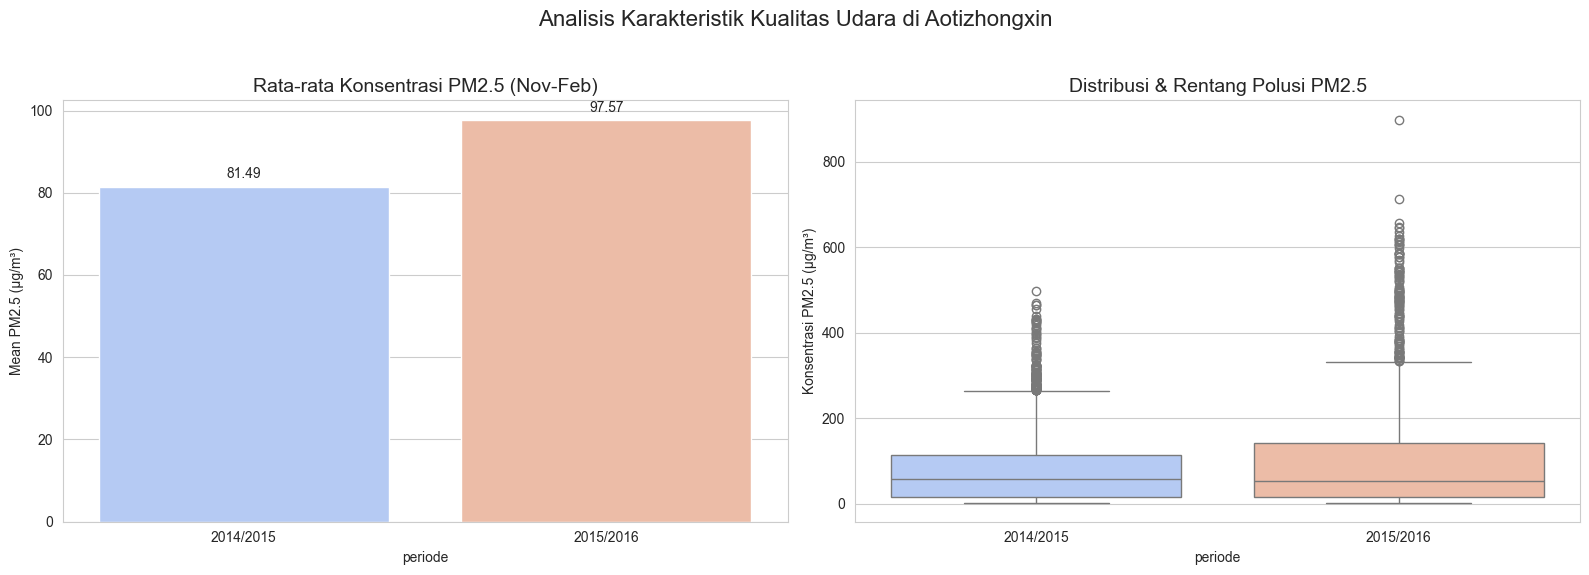

In [ ]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Grafik 1: Bar Chart Rata-rata
sns.barplot(x='periode', y='PM2.5', data=rata_pm25_aoti, palette='coolwarm', ax=ax[0])
ax[0].set_title('Rata-rata Konsentrasi PM2.5 (Nov-Feb)', fontsize=14)
ax[0].set_ylabel('Mean PM2.5 (µg/m³)')

# Tambah label angka
for p in ax[0].patches:
    ax[0].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

# Grafik 2: Box Plot untuk Karakteristik Distribusi
sns.boxplot(x='periode', y='PM2.5', data=aoti_dingin, palette='coolwarm', ax=ax[1])
ax[1].set_title('Distribusi & Rentang Polusi PM2.5', fontsize=14)
ax[1].set_ylabel('Konsentrasi PM2.5 (µg/m³)')

plt.suptitle('Analisis Karakteristik Kualitas Udara di Aotizhongxin', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Pertanyaan 2: Faktor meteorologi apa saja (TEMP, PRES, DEWP, RAIN, WSPM) yang memiliki korelasi paling signifikan terhadap fluktuasi konsentrasi PM2.5 di stasiun Wanliu selama tahun 2016?

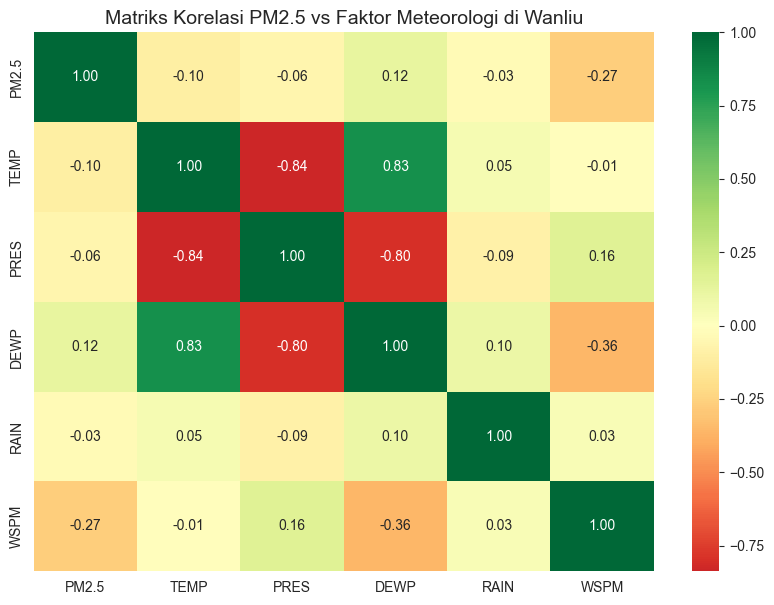

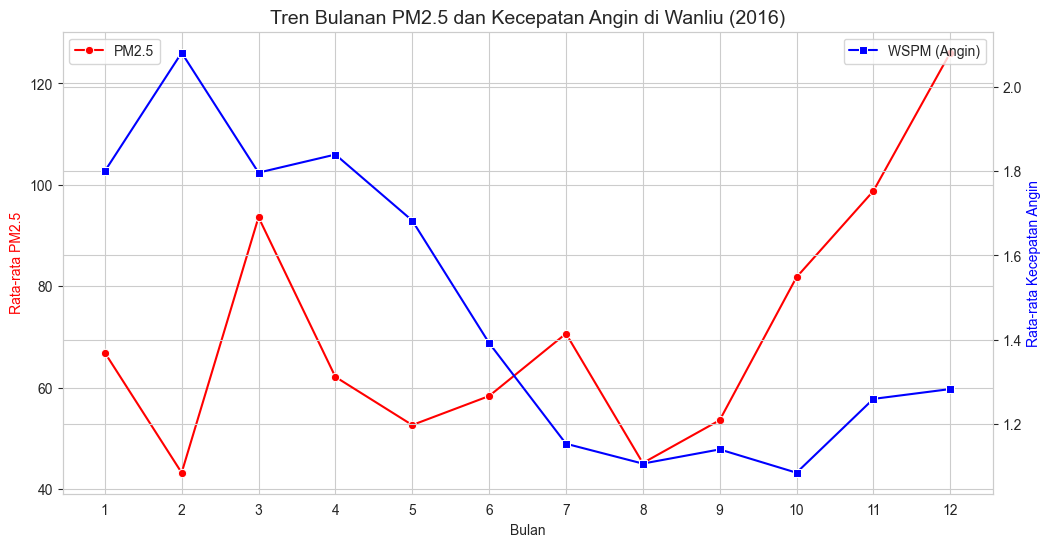

In [23]:
# Grafik 1: Heatmap Korelasi Lengkap
plt.figure(figsize=(10, 7))
sns.heatmap(matriks_korelasi, annot=True, cmap='RdYlGn', fmt=".2f", center=0)
plt.title('Matriks Korelasi PM2.5 vs Faktor Meteorologi di Wanliu', fontsize=14)
plt.show()

# Grafik 2: Tren Bulanan PM2.5 vs Kecepatan Angin (WSPM)
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

sns.lineplot(data=tren_bulanan_wanliu, x='month', y='PM2.5', marker='o', color='red', label='PM2.5', ax=ax1)
sns.lineplot(data=tren_bulanan_wanliu, x='month', y='WSPM', marker='s', color='blue', label='WSPM (Angin)', ax=ax2)

ax1.set_xlabel('Bulan')
ax1.set_ylabel('Rata-rata PM2.5', color='red')
ax2.set_ylabel('Rata-rata Kecepatan Angin', color='blue')
plt.title('Tren Bulanan PM2.5 dan Kecepatan Angin di Wanliu (2016)', fontsize=14)
plt.xticks(range(1, 13))
plt.show()

**Insight Pertanyaan 1:** 
- Rata-rata konsentrasi PM2.5 di stasiun Aotizhongxin pada musim dingin 2015/2016 (97,57 µg/m³) tercatat lebih tinggi secara signifikan dibandingkan periode 2014/2015 (81,49 µg/m³). Hal ini menunjukkan bahwa kualitas udara di wilayah tersebut justru mengalami penurunan kualitas pada periode kedua.
- Berdasarkan sebaran data pada box plot, periode 2015/2016 memiliki fluktuasi yang lebih ekstrem dengan munculnya titik-titik outliers yang mencapai angka di atas 900 µg/m³. Ini mengindikasikan bahwa lonjakan polusi parah lebih sering terjadi pada periode musim dingin yang kedua.
- Data ini menunjukkan bahwa kualitas udara di stasiun Aotizhongxin pada musim dingin periode kedua tidak hanya lebih buruk secara rata-rata, tetapi juga jauh lebih fluktuatif dengan frekuensi kejadian polusi ekstrem yang lebih tinggi dibandingkan periode sebelumnya.

**Insight Pertanyaan 2:** 
- Matriks korelasi menunjukkan bahwa kecepatan angin (WSPM) memiliki korelasi negatif sebesar -0,27 terhadap PM2.5. Meskipun tergolong korelasi lemah secara statistik, angka ini merupakan yang paling konsisten dibandingkan variabel meteorologi lainnya.
- Grafik tren bulanan memperlihatkan fenomena menarik di mana garis PM2.5 dan WSPM sering kali bergerak berlawanan arah. Sebagai contoh, pada bulan ke-2 saat kecepatan angin mencapai titik tertinggi, kadar PM2.5 berada di titik terendah. Sebaliknya, penurunan kecepatan angin secara drastis di akhir tahun (bulan 10–12) bertepatan dengan lonjakan tajam konsentrasi polutan.
- Fenomena ini membuktikan bahwa minimnya pergerakan angin menjadi pemicu utama penumpukan polutan di Wanliu, karena polutan tidak terdispersi dengan baik saat udara tenang.

## Analisis Lanjutan: Distribusi PM2.5 Bulanan di Wanliu Selama Tahun 2016

C:\Users\nurul\AppData\Local\Temp\ipykernel_14108\1505058962.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='month', y='PM2.5', data=wanliu_2016, palette='viridis')


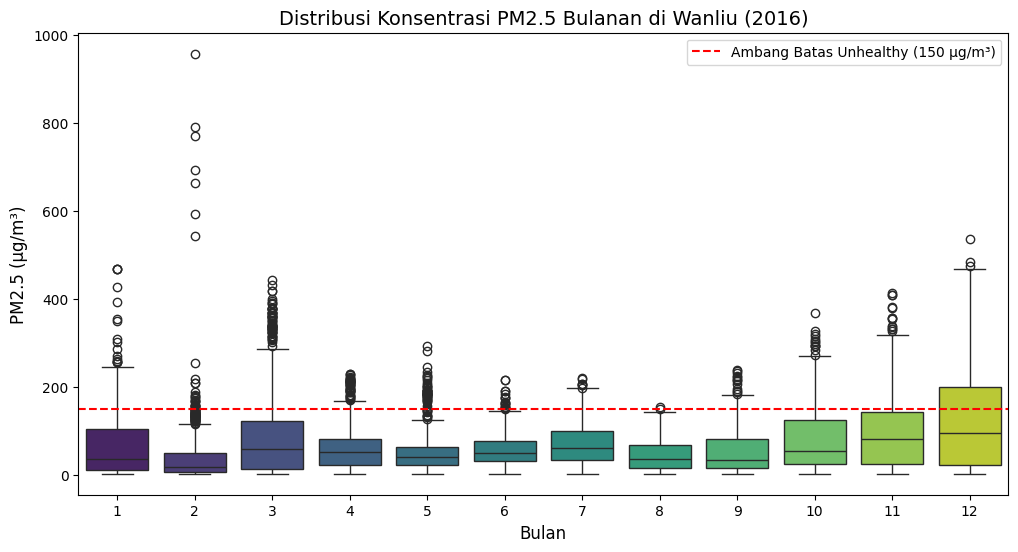

In [ ]:
# Analisis untuk melihat sebaran polusi per bulan di Wanliu
plt.figure(figsize=(12, 6))
wanliu_2016 = main_df[(main_df['station'] == 'Wanliu') & (main_df['year'] == 2016)]

sns.boxplot(x='month', y='PM2.5', data=wanliu_2016, palette='viridis')
plt.axhline(y=150, color='red', linestyle='--', label='Ambang Batas Unhealthy (150 µg/m³)')

plt.title('Distribusi Konsentrasi PM2.5 Bulanan di Wanliu (2016)', fontsize=14)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('PM2.5 (µg/m³)', fontsize=12)
plt.legend()
plt.show()

**Insight Lanjutan:** 
- Visualisasi menunjukkan bahwa bulan November dan Desember memiliki rentang antarkuartil (interquartile range) yang paling lebar dan posisi kotak yang paling tinggi. Hal ini mengindikasikan bahwa pada akhir tahun, konsentrasi polutan tidak hanya meningkat secara rata-rata, tetapi juga memiliki variabilitas yang sangat tinggi dengan frekuensi status udara di atas ambang batas Unhealthy yang sangat sering.
- Terdapat sebaran pencilan (outliers) yang signifikan pada beberapa bulan tertentu, di mana konsentrasi PM2.5 melonjak ekstrem melampaui angka 600 $\mu g/m^3$ hingga mendekati 1000 $\mu g/m^3$. Temuan ini mengonfirmasi adanya anomali polusi udara yang sangat berat pada jam-jam tertentu, meskipun secara median bulanan terlihat lebih rendah dibandingkan puncak musim dingin.
-  Sebaliknya, pada periode pertengahan tahun (seperti bulan Juli dan Agustus), mayoritas sebaran data berada secara konsisten di bawah garis ambang batas merah (150 $\mu g/m^3$). Pola ini memvalidasi bahwa kondisi cuaca pada musim panas cenderung lebih efektif dalam menjaga konsentrasi polutan tetap pada level yang lebih aman bagi kesehatan masyarakat dibandingkan periode akhir tahun.
  * Catatan: Garis ambang batas 150 $\mu g/m^3$ merujuk pada standar kategori "Unhealthy" menurut US-EPA Air Quality Index (AQI) untuk polutan PM2.5.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** 
Analisis pada stasiun Aotizhongxin menunjukkan bahwa kualitas udara pada periode musim dingin justru mengalami tren penurunan. Terjadi kenaikan rata-rata konsentrasi PM2.5 sebesar 19,7%, yaitu dari 81,49 $\mu g/m^3$ (periode 2014-2015) menjadi 97,57 $\mu g/m^3$ (periode 2015-2016). Selain kenaikan rata-rata, grafik box plot mengonfirmasi adanya peningkatan frekuensi polusi ekstrem dengan outliers yang mencapai angka di atas 900 $\mu g/m^3$ pada periode kedua. Hal ini menunjukkan bahwa upaya pengendalian emisi musiman belum efektif meredam lonjakan polutan di wilayah tersebut.

- **Conclusion pertanyaan 2:** 
Di stasiun Wanliu (2016), faktor meteorologi yang memiliki hubungan paling konsisten terhadap fluktuasi PM2.5 adalah Kecepatan Angin (WSPM) dengan koefisien korelasi negatif sebesar -0,27. Sebaliknya, suhu (TEMP) hanya memiliki korelasi yang sangat lemah sebesar -0,10. Visualisasi tren bulanan divalidasi oleh pola inversi; lonjakan polusi tertinggi terjadi pada bulan November dan Desember saat kecepatan angin berada di titik terendah. Analisis distribusi bulanan menunjukkan bahwa pada akhir tahun, mayoritas data (kuartil atas) berada di atas ambang batas Unhealthy (150 $\mu g/m^3$), yang menegaskan bahwa minimnya dispersi udara oleh angin menjadi pemicu utama penumpukan polutan.

**Rekomendasi Action Item:**

Stasiun Aotizhongxin: Fokus Evaluasi & Mitigasi Ekstrem
- Audit Kebijakan Musim Dingin: Melakukan peninjauan ulang terhadap efektivitas pembatasan industri dan penggunaan pemanas di sekitar stasiun Aotizhongxin. Mengingat konsentrasi PM2.5 justru naik 19,7% pada periode musim dingin terbaru, perlu dievaluasi apakah regulasi sudah dijalankan dengan ketat atau butuh parameter pembatasan baru.
- Investigasi & Mitigasi Lonjakan Ekstrem: Berdasarkan temuan outliers yang melonjak ekstrem hingga di atas 900 $\mu g/m^3$ pada musim dingin, pemerintah perlu menempatkan tim respons cepat untuk mengidentifikasi sumber emisi sporadis (seperti pembakaran ilegal atau kegagalan filter industri) yang menyebabkan lonjakan instan tersebut.

Stasiun Wanliu: Fokus Adaptasi Meteorologi & Edukasi
- Sistem Peringatan Dini Berbasis Kecepatan Angin: Mengembangkan protokol peringatan dini bagi warga Wanliu, khususnya institusi pendidikan dan pemukiman. Berdasarkan korelasi negatif -0,27, sistem harus memberikan notifikasi otomatis untuk membatasi aktivitas luar ruangan saat prakiraan kecepatan angin berada di titik rendah (kondisi udara tenang).
- Manajemen Polusi di Bulan Kritis (Kuartal Terakhir): Memprioritaskan pengalihan arus lalu lintas atau penghentian sementara aktivitas konstruksi di Wanliu pada bulan November dan Desember. Data box plot bulanan menunjukkan periode ini memiliki risiko kesehatan tertinggi dengan median sering melampaui ambang batas 150 $\mu g/m^3$.
- Edukasi Kualitas Udara & Ambang Batas: Mengedukasi masyarakat mengenai signifikansi ambang batas Unhealthy (150 $\mu g/m^3$) sesuai standar US-EPA AQI. Masyarakat butuh akses informasi real-time agar lebih waspada pada jam-jam dengan kategori "Sangat Tidak Sehat" yang frekuensinya meningkat tajam di akhir tahun.